# EDA

### EDA (Exploratory Data Analysis) is the process of understanding my dataset before building a machine learning model. In my movie success prediction project, EDA helps me to discover patterns, missing values, outliers, and relationships with imdb_score.

In [1]:
# imports 
import pandas as pd
import sys
from pathlib import Path
PROJECT_ROOT= Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_data
from src.preprocessing import build_preprocessor
import seaborn as sns 
import matplotlib.pyplot as plt

The configurations are successfully applied
The preprocessing step is completed


In [2]:
## Loading data
df = load_data()

print(df.shape)
df.head()

(5043, 21)


,color,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,genres,num_voted_users,cast_total_facebook_likes,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,723.0,178.0,0.0,855.0,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,886204,4834,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,302.0,169.0,563.0,1000.0,40000.0,309404152.0,Action|Adventure|Fantasy,471220,48350,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,602.0,148.0,0.0,161.0,11000.0,200074175.0,Action|Adventure|Thriller,275868,11700,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,813.0,164.0,22000.0,23000.0,27000.0,448130642.0,Action|Thriller,1144337,106759,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,NaN,NaN,131.0,NaN,131.0,NaN,Documentary,8,143,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [3]:
## Checking basic information
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [4]:
## Checking missing values
df.isnull().sum()

color                         19
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_1_facebook_likes         7
gross                        884
genres                         0
num_voted_users                0
cast_total_facebook_likes      0
facenumber_in_poster          13
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64

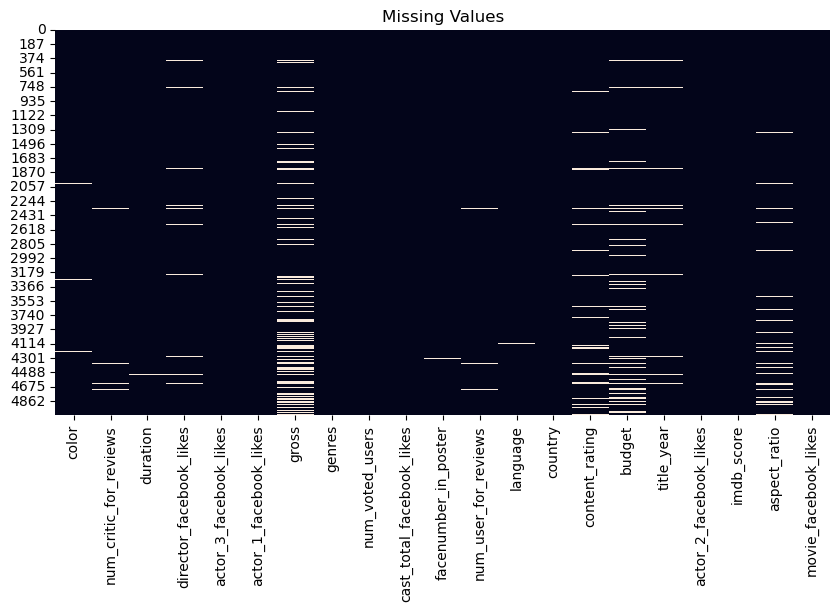

In [10]:
## Visulaization

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)   # cbar = false means color scale bar will not appear
plt.title("Missing Values")
plt.show()

In [5]:
## Imputations
df_num = df.select_dtypes(include=['int64','float64'])

df_num = df_num.fillna(df_num.median())

df_cat = df.select_dtypes(include=['object'])

df_cat = df_cat.fillna(df_cat.mode().iloc[0])

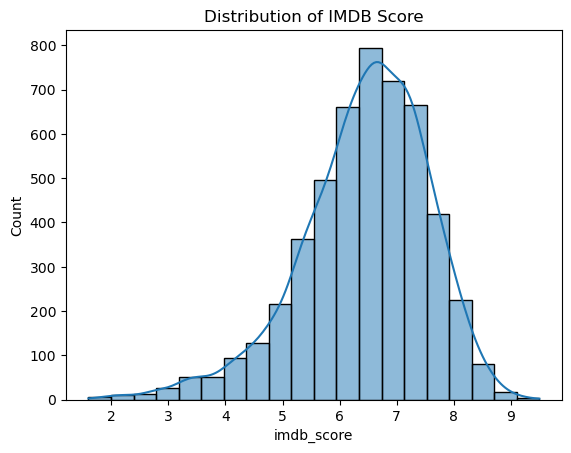

In [6]:
## Distribution of imdb score(target column)
sns.histplot(df["imdb_score"], bins=20, kde=True)
plt.title("Distribution of IMDB Score")
plt.show()

In [7]:
## Creating movie success categories
def classify_movie(score):
    if score <= 3:
        return "Flop"
    elif score <= 6:
        return "Average"
    else:
        return "Hit"

df["Classify"] = df["imdb_score"].apply(classify_movie)

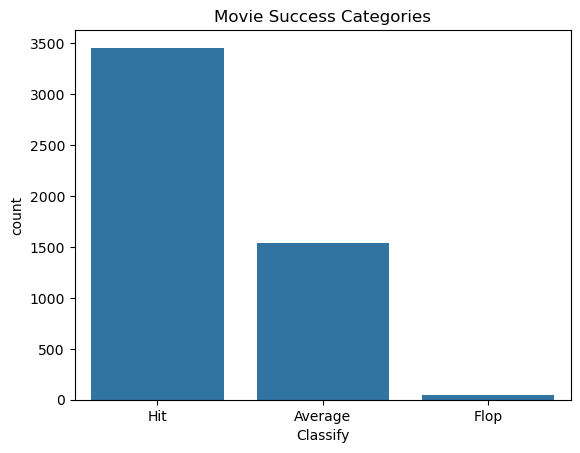

In [8]:
sns.countplot(x="Classify", data=df)
plt.title("Movie Success Categories")
plt.show()

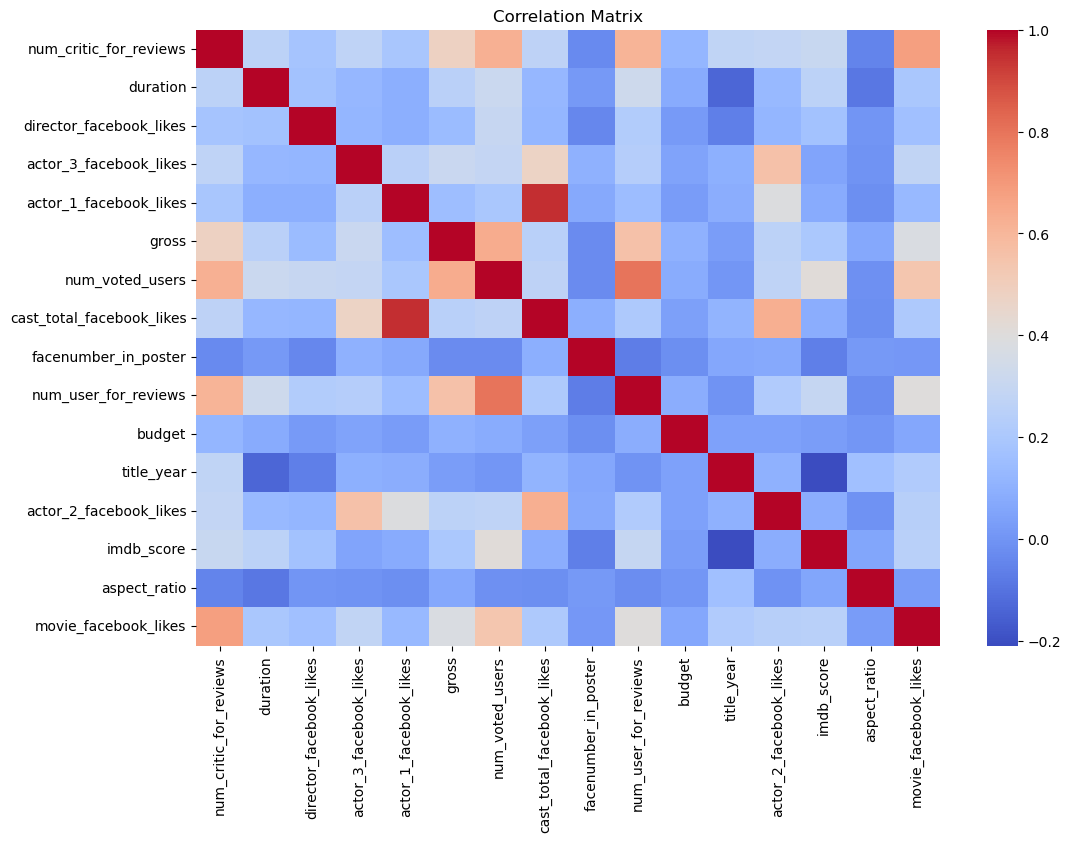

In [9]:
## Correlation analysis
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#### The correlation analysis indicates that num_voted_users has the strongest positive relationship with imdb_score, suggesting that more popular movies tend to receive higher ratings. Revenue (gross) is also positively correlated with user votes, indicating that widely watched movies generate higher box office returns. Social media engagement features such as actor and movie Facebook likes show moderate correlations with audience engagement metrics. However, budget and release year exhibit weak relationships with IMDB scores, suggesting that financial investment or release timing alone does not determine movie success.

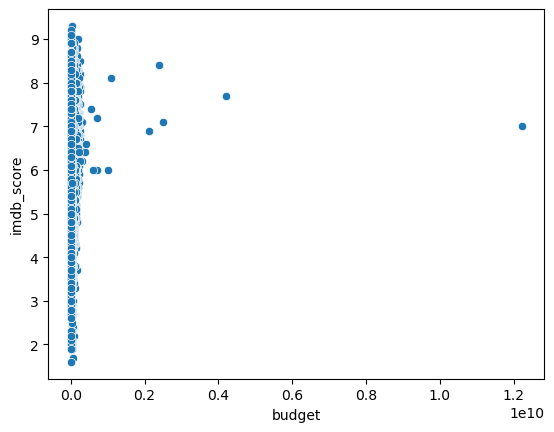

In [10]:
## Relationship plots
sns.scatterplot(x="budget", y="imdb_score", data=df)
plt.show()

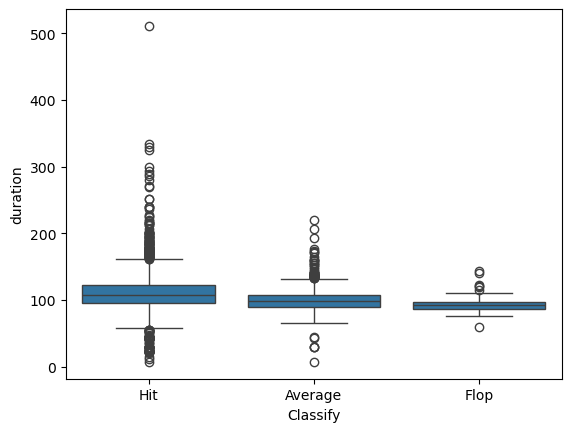

In [11]:
sns.boxplot(x="Classify", y="duration", data=df)
plt.show()

### Conclusions
- num_voted_users has the strongest relationship with imdb_score
- num_user_for_reviews is also related to movie popularity
- gross and num_voted_users
- Facebook likes features are correlated
- budget has weak correlation with imdb_score
- title_year has slight negative correlation with imdb_score